In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression ,LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,Normalizer,MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [2]:
df=pd.read_csv("social.csv")
x=df.iloc[:,2:4]
y=df.iloc[:,4] # using 1:3 as indicies will give an array of dim (10,1)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [4]:
x_sca=StandardScaler()
x_train=x_sca.fit_transform(x_train)
x_test=x_sca.transform(x_test)


In [5]:
clf=LogisticRegression(random_state=0)
clf.fit(x_train,y_train)

LogisticRegression(random_state=0)

In [6]:
y_pread=clf.predict(x_test)
print(y_pread)

[1 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 1 0 1 1 1 0 0 1 0 1
 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0
 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0]


In [7]:
acc=accuracy_score(y_test,y_pread)
print(f"the accuracy is :{acc}")
cr=classification_report(y_test,y_pread)
print(cr)

the accuracy is :0.85
              precision    recall  f1-score   support

           0       0.89      0.88      0.89        66
           1       0.77      0.79      0.78        34

    accuracy                           0.85       100
   macro avg       0.83      0.84      0.83       100
weighted avg       0.85      0.85      0.85       100



# KNN Algo

In [8]:
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [9]:
x_sca=StandardScaler()
x_train=x_sca.fit_transform(x_train)
x_test=x_sca.transform(x_test)

In [10]:
clf=KNeighborsClassifier(n_neighbors=5,metric="minkowski",p=2)
clf=clf.fit(x_train,y_train)

In [11]:
y_pread=clf.predict(x_test)
y_pread

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0], dtype=int64)

In [12]:
cm=confusion_matrix(y_test,y_pread)
cm

array([[57,  8],
       [ 5, 30]], dtype=int64)

In [13]:
acc=accuracy_score(y_test,y_pread)
print(f"the accuracy is :{acc}")
cr=classification_report(y_test,y_pread)
print(cr)

the accuracy is :0.87
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        65
           1       0.79      0.86      0.82        35

    accuracy                           0.87       100
   macro avg       0.85      0.87      0.86       100
weighted avg       0.87      0.87      0.87       100



# DT ALGO

In [49]:
# # creating data frome here 
# data = {
#     'Age':           ['<=30', '<=30', '31-40', '>40', '>40', '>40', '31-40', '<=30', '<=30', '>40'],
#     'Income':        ['High', 'High', 'High', 'Med', 'Low', 'Low', 'Low', 'Med', 'Low', 'Med'],
#     'Student':       ['No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes'],
#     'Credit_Rating': ['Fair', 'Excellent', 'Fair', 'Fair', 'Fair', 'Excellent', 'Excellent', 'Fair', 'Fair', 'Fair'],
#     'Buys_Computer': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
# }


data2 = {
    'Age':    ['OLD', 'OLD', 'OLD', 'MED','MED ','MED', 'MED','NEW', 'NEW', 'NEW'],
    'Comp':   ['YES', 'No',  'No',  'YES','YES','No', 'No',  'YES', 'No',  'No'],
    'Type':   ['Software','Software', 'Hardware', 'Software', 'Hardware',"Hardware", 'Software', 'Software', 'Hardware', 'Software'],
    'Profit': ['Down', 'Down', 'Down','Down', 'Down', 'UP', 'UP', 'UP', 'UP', 'UP']
}
df = pd.DataFrame(data2)


In [50]:
x=pd.get_dummies(df.drop("Profit",axis=1))
x

,Age_MED,Age_MED,Age_NEW,Age_OLD,Comp_No,Comp_YES,Type_Hardware,Type_Software
0,False,False,False,True,False,True,False,True
1,False,False,False,True,True,False,False,True
2,False,False,False,True,True,False,True,False
3,True,False,False,False,False,True,False,True
4,False,True,False,False,False,True,True,False
5,True,False,False,False,True,False,True,False
6,True,False,False,False,True,False,False,True
7,False,False,True,False,False,True,False,True
8,False,False,True,False,True,False,True,False
9,False,False,True,False,True,False,False,True


In [51]:

y=df["Profit"].map({"Down":0,"UP":1})
y

x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [52]:
model=DecisionTreeClassifier(criterion="entropy",random_state=0,max_depth=3)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [29]:

# x_sca=StandardScaler()
# x_train=x_sca.fit_transform(x_train)
# x_test=x_sca.transform(x_test)

In [60]:
y_pread=model.predict(x_test)
y_pread

array([0, 1, 0], dtype=int64)

In [62]:
Accuracy_score=accuracy_score(y_test,y_pread)
print(f"The accuracy score by using entropy is :{Accuracy_score }")

The accuracy score by using entropy is :1.0


In [63]:
clf_report=classification_report(y_test,y_pread)
print(clf_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



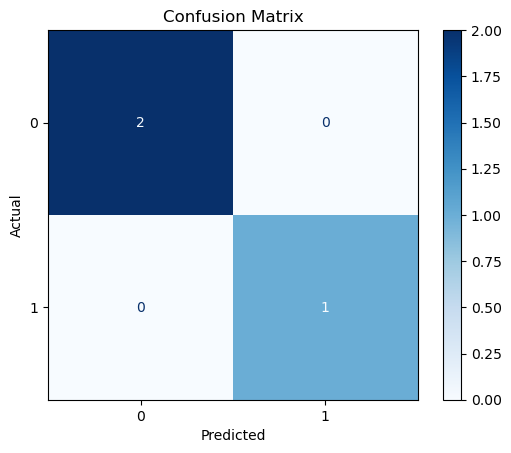

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pread)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

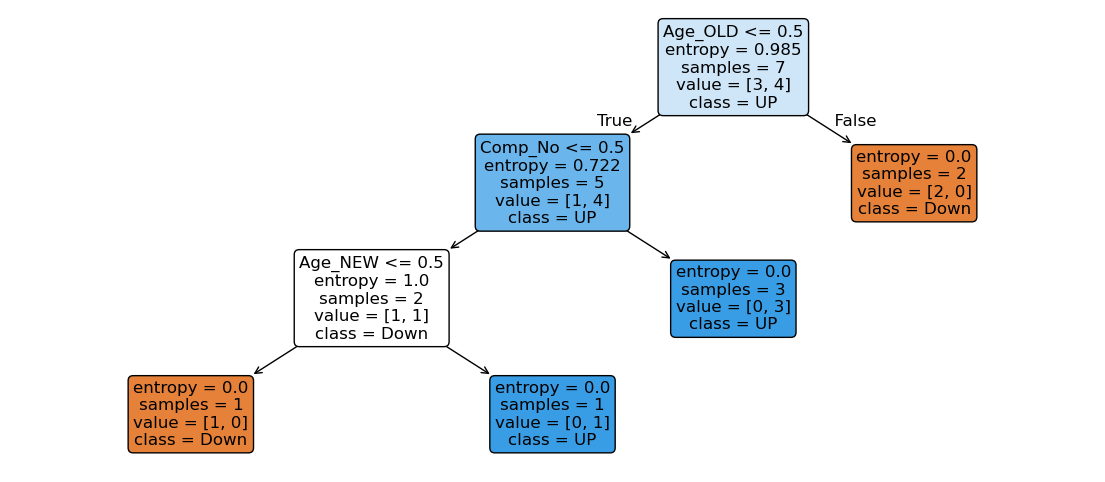

In [74]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plot_tree(model,
          max_depth=3,
          feature_names=list(x.columns),        # ✅ convert to list
          class_names=['Down', 'UP'],      # ✅ convert to list
          filled=True,
          rounded=True,
          fontsize=12)
plt.show()

# DT compaarioson

In [2]:
df=pd.read_csv("social.csv")
xd=df.iloc[:,2:4]
yd=df.iloc[:,4] # using 1:3 as indicies will give an array of dim (10,1)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [7]:
# df["Purchased"].dtype

dtype('int64')

In [9]:
xd=pd.get_dummies(df.drop("Purchased",axis=1))
xd

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,19,19000,False,True
1,15810944,35,20000,False,True
2,15668575,26,43000,True,False
3,15603246,27,57000,True,False
4,15804002,19,76000,False,True
...,...,...,...,...,...
395,15691863,46,41000,True,False
396,15706071,51,23000,False,True
397,15654296,50,20000,True,False
398,15755018,36,33000,False,True


In [10]:
xd_train, xd_test,yd_train,yd_test=train_test_split(xd,yd,test_size=0.25)

In [12]:
ml=DecisionTreeClassifier(criterion="entropy",random_state=0,max_depth=3)
ml.fit(xd_train,yd_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [16]:
yd_pread=ml.predict(xd_test)
y_pread

array([0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1], dtype=int64)

In [17]:
Accuracy_score=accuracy_score(yd_test,yd_pread)
print(f"The accuracy score by using entropy is :{Accuracy_score }")

The accuracy score by using entropy is :0.93
